## Exploratory Data Analysis

Customer Service Chatbot — multi-class text classification task.  
Dataset: `ds_task_dataset.csv` — 2,169 labeled customer queries across 10 financial categories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

LABEL_MAP = {
    0: "CARD_PAYMENT_FEE_CHARGED",
    1: "DIRECT_DEBIT_PAYMENT_NOT_RECOGNISED",
    2: "BALANCE_NOT_UPDATED_AFTER_CHEQUE_OR_CASH_DEPOSIT",
    3: "WRONG_AMOUNT_OF_CASH_RECEIVED",
    4: "CASH_WITHDRAWAL_CHARGE",
    5: "TRANSACTION_CHARGED_TWICE",
    6: "DECLINED_CASH_WITHDRAWAL",
    7: "TRANSFER_FEE_CHARGED",
    8: "TRANSFER_NOT_RECEIVED_BY_RECIPIENT",
    9: "BALANCE_NOT_UPDATED_AFTER_BANK_TRANSFER",
}

SHORT_LABEL = {
    0: "CardPayFee",
    1: "DirectDebitUnknown",
    2: "BalNotUpdCheque",
    3: "WrongCashAmt",
    4: "CashWithdrawCharge",
    5: "ChargedTwice",
    6: "DeclinedWithdraw",
    7: "TransferFee",
    8: "TransferNotRecvd",
    9: "BalNotUpdTransfer",
}

df = pd.read_csv("ds_task_dataset.csv")
df["label_name"] = df["label"].map(LABEL_MAP)
df["label_short"] = df["label"].map(SHORT_LABEL)
df.head(10)

,text,label,label_name,label_short
0,Why did I only receive a partial amount of wha...,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
1,my atm transaction was wrong,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
2,why did i only get 20.00,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
3,Why is my cash request and the amount I receiv...,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
4,"I tried to withdraw $100, all it gave me was $20.",3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
5,The ATM didn't give me enough money.,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
6,When I went to withdraw cash today the ATM gav...,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
7,I didn't get the all the cash i wanted from th...,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
8,I received $20 but I entered $100,3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt
9,"Hi, I used an ATM today to take money out of m...",3,WRONG_AMOUNT_OF_CASH_RECEIVED,WrongCashAmt


### 1. Basic Dataset Info

In [2]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df["text"].duplicated().sum())
print("\nUnique labels:", sorted(df["label"].unique()))

Shape: (2169, 4)

Column dtypes:
text           object
label           int64
label_name     object
label_short    object
dtype: object

Missing values:
text           0
label          0
label_name     0
label_short    0
dtype: int64

Duplicate rows: 0
Duplicate texts: 0

Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### 2. Class Distribution

                                           Label  Count  Pct (%)
                        CARD_PAYMENT_FEE_CHARGED    227    10.47
             DIRECT_DEBIT_PAYMENT_NOT_RECOGNISED    222    10.24
BALANCE_NOT_UPDATED_AFTER_CHEQUE_OR_CASH_DEPOSIT    221    10.19
                   WRONG_AMOUNT_OF_CASH_RECEIVED    220    10.14
                          CASH_WITHDRAWAL_CHARGE    217    10.00
                       TRANSACTION_CHARGED_TWICE    215     9.91
                        DECLINED_CASH_WITHDRAWAL    213     9.82
                            TRANSFER_FEE_CHARGED    212     9.77
              TRANSFER_NOT_RECEIVED_BY_RECIPIENT    211     9.73
         BALANCE_NOT_UPDATED_AFTER_BANK_TRANSFER    211     9.73

Total samples: 2169
Class imbalance ratio (max/min): 1.08x


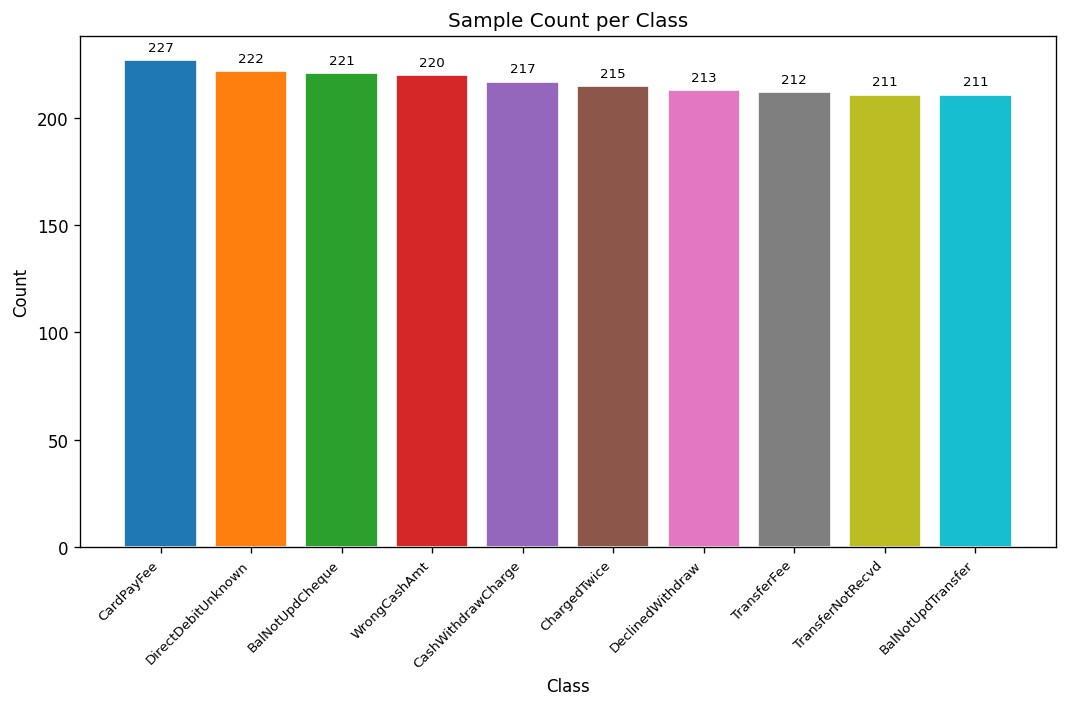

In [3]:
class_counts = df["label"].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

summary = pd.DataFrame({
    "Label": [LABEL_MAP[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Pct (%)": class_pct.values,
})
print(summary.to_string(index=False))
print(f"\nTotal samples: {len(df)}")
print(f"Class imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}x")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(
    [SHORT_LABEL[i] for i in class_counts.index],
    class_counts.values,
    color=sns.color_palette("tab10", 10),
    edgecolor="white",
)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(count), ha="center", va="bottom", fontsize=8)
ax.set_title("Sample Count per Class")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

### 3. Text Length Analysis

=== Character Count ===
count    2169.0
mean       76.1
std        53.2
min        15.0
25%        44.0
50%        56.0
75%        86.0
max       409.0

=== Word Count ===


count    2169.0
mean       15.1
std        10.3
min         2.0
25%         9.0
50%        11.0
75%        17.0
max        78.0


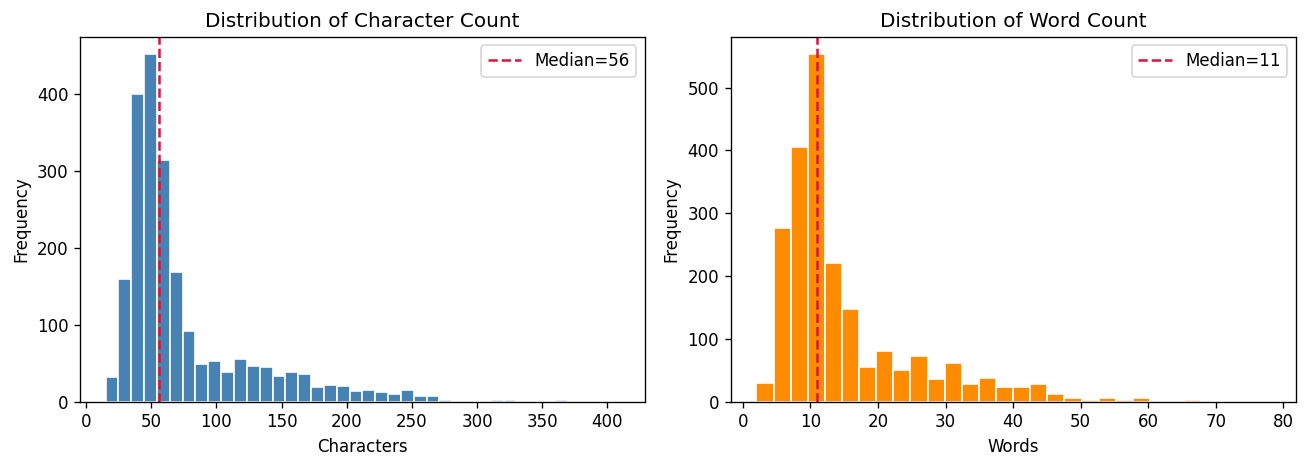

In [4]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("=== Character Count ===")
print(df["char_count"].describe().round(1).to_string())
print("\n=== Word Count ===")
print(df["word_count"].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["char_count"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(df["char_count"].median(), color="crimson", linestyle="--", label=f"Median={df['char_count'].median():.0f}")
axes[0].set_title("Distribution of Character Count")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df["word_count"], bins=30, color="darkorange", edgecolor="white")
axes[1].axvline(df["word_count"].median(), color="crimson", linestyle="--", label=f"Median={df['word_count'].median():.0f}")
axes[1].set_title("Distribution of Word Count")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Text Length by Class

                   char_count              word_count             
                         mean median   std       mean median   std
label_short                                                       
BalNotUpdCheque          71.9   63.0  32.9       14.2   13.0   6.5
BalNotUpdTransfer        74.4   58.0  42.6       14.4   11.0   8.6
CardPayFee               65.1   53.0  37.8       13.7   11.0   7.2
CashWithdrawCharge       71.3   52.0  46.9       14.2   11.0   8.9
ChargedTwice             84.0   52.0  71.6       16.0   10.0  13.7
DeclinedWithdraw         67.5   49.0  42.6       13.8   10.0   8.5
DirectDebitUnknown       78.2   60.0  51.6       15.8   12.0  10.4
TransferFee              87.0   54.0  73.9       16.9   11.0  13.7
TransferNotRecvd         89.5   57.0  65.7       17.1   11.0  12.8
WrongCashAmt             72.7   54.5  45.9       15.3   12.0   9.5


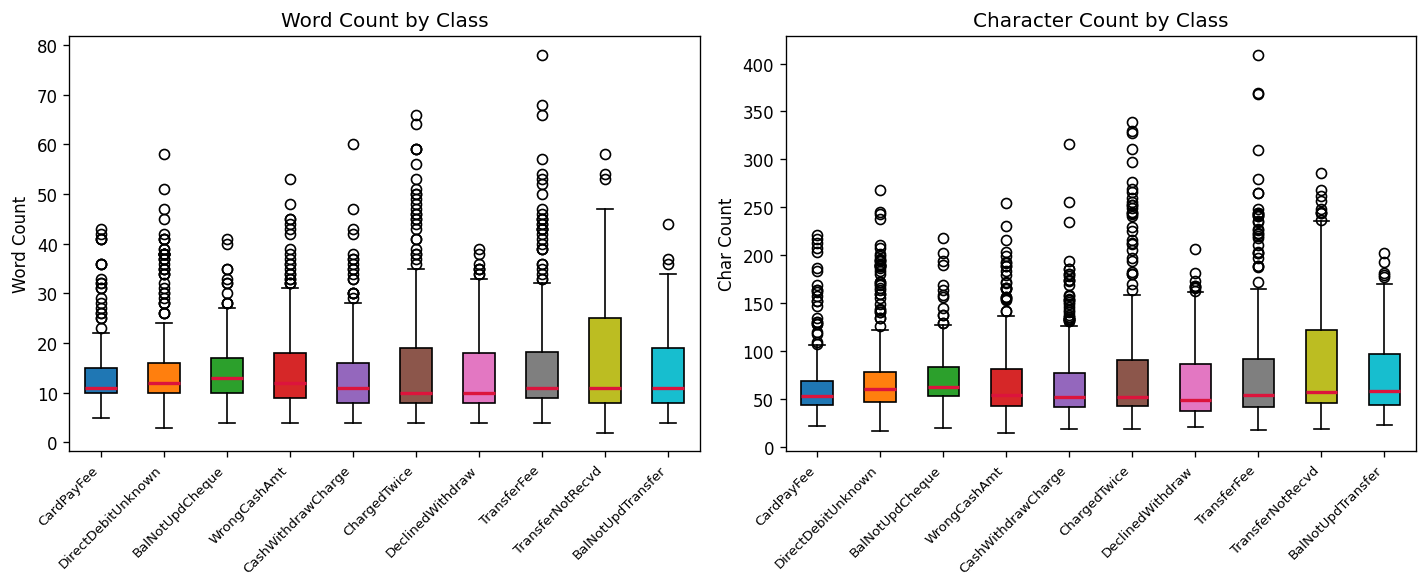

In [5]:
length_by_class = (
    df.groupby("label_short")[["char_count", "word_count"]]
    .agg(["mean", "median", "std"])
    .round(1)
)
print(length_by_class.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ordered_labels = [SHORT_LABEL[i] for i in range(10)]

bp1 = axes[0].boxplot(
    [df[df["label_short"] == lbl]["word_count"].values for lbl in ordered_labels],
    labels=ordered_labels,
    patch_artist=True,
    medianprops=dict(color="crimson", linewidth=2),
)
for patch, color in zip(bp1["boxes"], sns.color_palette("tab10", 10)):
    patch.set_facecolor(color)
axes[0].set_title("Word Count by Class")
axes[0].set_ylabel("Word Count")
axes[0].set_xticklabels(ordered_labels, rotation=45, ha="right", fontsize=8)

bp2 = axes[1].boxplot(
    [df[df["label_short"] == lbl]["char_count"].values for lbl in ordered_labels],
    labels=ordered_labels,
    patch_artist=True,
    medianprops=dict(color="crimson", linewidth=2),
)
for patch, color in zip(bp2["boxes"], sns.color_palette("tab10", 10)):
    patch.set_facecolor(color)
axes[1].set_title("Character Count by Class")
axes[1].set_ylabel("Char Count")
axes[1].set_xticklabels(ordered_labels, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

### 5. Sample Queries per Class

In [6]:
rng = np.random.default_rng(42)

for label_id in range(10):
    subset = df[df["label"] == label_id]["text"].values
    samples = rng.choice(subset, size=min(3, len(subset)), replace=False)
    print(f"\n[{label_id}] {LABEL_MAP[label_id]}")
    for s in samples:
        print(f"  • {s}")


[0] CARD_PAYMENT_FEE_CHARGED
  • I just saw a fee on my account. When do these get charged?
  • Why was my transaction charged an extra fee when paying with my card?
  • When do you charge fees on accounts? I just saw a charge on my statement.

[1] DIRECT_DEBIT_PAYMENT_NOT_RECOGNISED
  • Please tell me what this direct debit in my statement is
  • I don't know what this Direct Debit payment on my account is for.
  • someone stole my money

[2] BALANCE_NOT_UPDATED_AFTER_CHEQUE_OR_CASH_DEPOSIT
  • I put money in my account a week ago but its still not there?? What happened to my money?
  • Has the check I deposited cleared to I can get the cash?
  • I deposited a cheque, but the balance hasn't changed yet.

[3] WRONG_AMOUNT_OF_CASH_RECEIVED
  • When I went to $100, all the machine would give me was $20.
  • I visited the ATM but got less money than what I requested. Why?
  • I went tot the ATM earlier today and didn't realize this till now but I did not get all the money I requested.  I

### 6. Most Frequent Words per Class (after stopword removal)

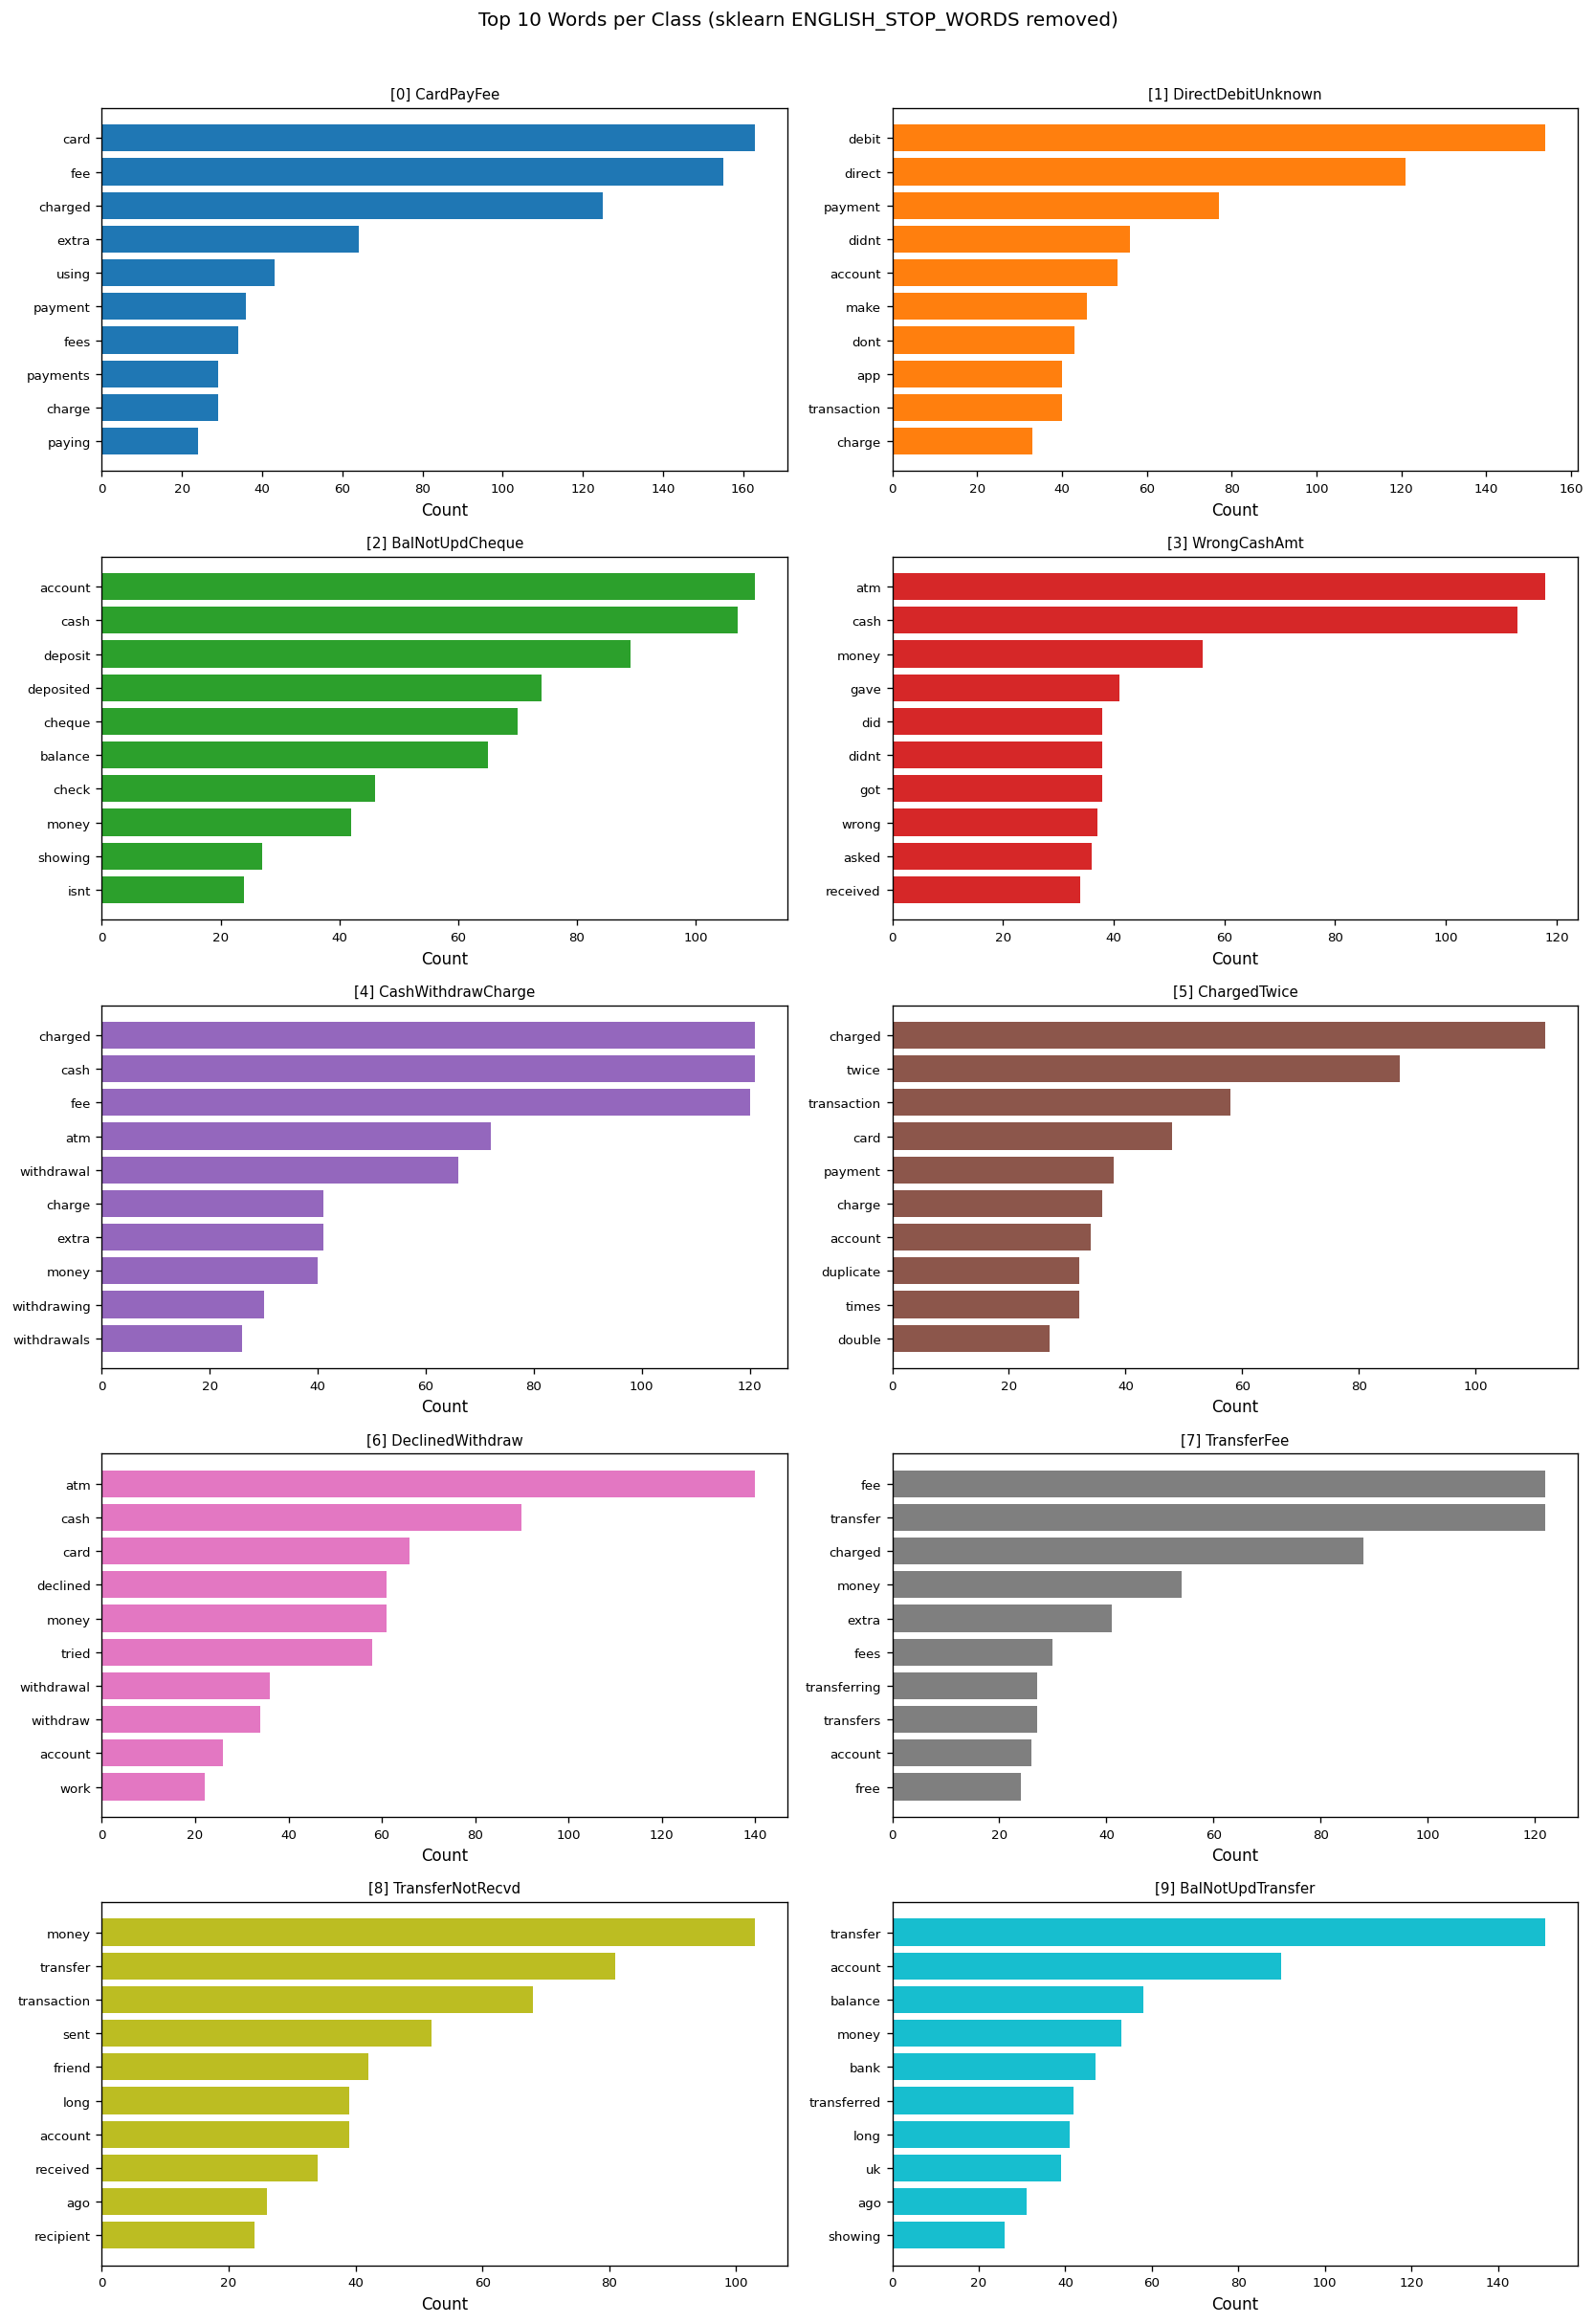

In [7]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def top_words(texts, n=10):
    tokens = []
    for text in texts:
        words = re.sub(r"[^a-z\s]", "", text.lower()).split()
        tokens.extend([w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 1])
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()
palette = sns.color_palette("tab10", 10)

for label_id in range(10):
    subset = df[df["label"] == label_id]["text"].values
    top = top_words(subset, n=10)
    words, counts = zip(*top)
    ax = axes[label_id]
    ax.barh(list(words)[::-1], list(counts)[::-1], color=palette[label_id])
    ax.set_title(f"[{label_id}] {SHORT_LABEL[label_id]}", fontsize=9)
    ax.set_xlabel("Count")
    ax.tick_params(labelsize=8)

plt.suptitle("Top 10 Words per Class (sklearn ENGLISH_STOP_WORDS removed)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 7. Vocabulary & Lexical Statistics

Total tokens (corpus size):   32,673
Unique tokens (vocabulary):   1,153
Type-Token Ratio (TTR):       0.0353
Top-10 most frequent tokens:  [('i', 2421), ('a', 1205), ('my', 1177), ('the', 1139), ('to', 788), ('why', 581), ('is', 566), ('for', 555), ('was', 536), ('it', 509)]

Singleton words (freq=1):     436


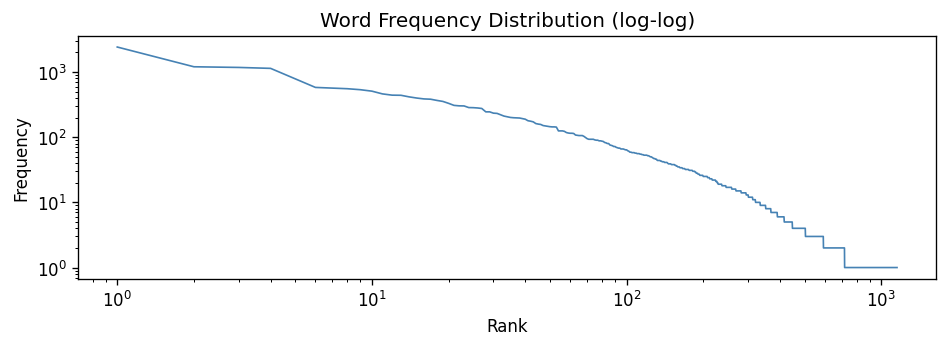

In [8]:
all_tokens = []
for text in df["text"]:
    all_tokens.extend(re.sub(r"[^a-z\s]", "", text.lower()).split())

vocab = set(all_tokens)
token_freq = Counter(all_tokens)

print(f"Total tokens (corpus size):   {len(all_tokens):,}")
print(f"Unique tokens (vocabulary):   {len(vocab):,}")
print(f"Type-Token Ratio (TTR):       {len(vocab)/len(all_tokens):.4f}")
print(f"Top-10 most frequent tokens:  {token_freq.most_common(10)}")
print(f"\nSingleton words (freq=1):     {sum(1 for v in token_freq.values() if v == 1):,}")

# Zipf-like frequency plot
freqs = sorted(token_freq.values(), reverse=True)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(freqs) + 1), freqs, lw=1, color="steelblue")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Word Frequency Distribution (log-log)")
ax.set_xlabel("Rank")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

### 8. Inter-Class Vocabulary Overlap

How many vocabulary words are shared across classes vs. unique to a single class? High overlap implies classes are harder to separate with bag-of-words features alone.

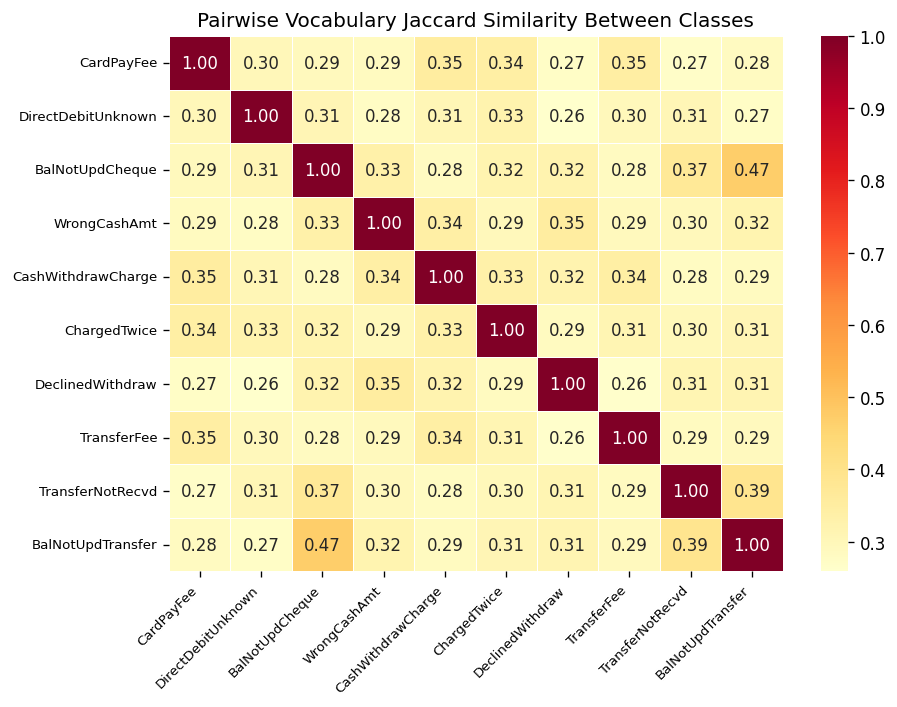

Words found exclusively in one class (not in any other):
  [0] CardPayFee: ['warned', 'pattern', 'others', 'idea', 'associated', 'feel', 'instances', 'cat', 'read', 'allowances']
  [1] DirectDebitUnknown: ['dispute', 'recognize', 'months', 'large', 'remember', 'statements', 'authorize', 'late', 'approve', 'recognise']
  [2] BalNotUpdCheque: ['cheque', 'depositing', 'cheques', 'faster', 'slow', 'checque', 'submitted', 'deposits', 'system', 'almost']
  [3] WrongCashAmt: ['gave', 'asked', 'pounds', 'given', 'specified', 'standing', 'wd', 'application', 'match', 'distributed']
  [4] CashWithdrawCharge: ['groceries', 'grocery', 'assessed', 'question', 'unnecessary', 'concerning', 'carry', 'per', 'robbing', 'accountthis']
  [5] ChargedTwice: ['duplicate', 'once', 'restaurant', 'duplicated', 'stays', 'works', 'single', 'review', 'meal', 'accurate']
  [6] DeclinedWithdraw: ['declining', 'notting', 'hill', 'wont', 'keeps', 'pin', 'frozen', 'allow', 'denied', 'refused']
  [7] TransferFee: ['abro

In [9]:
class_vocabs = {}
for label_id in range(10):
    texts = df[df["label"] == label_id]["text"]
    tokens = set()
    for text in texts:
        tokens.update(re.sub(r"[^a-z\s]", "", text.lower()).split())
    class_vocabs[label_id] = tokens

# Jaccard similarity matrix
n = 10
jaccard = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        inter = len(class_vocabs[i] & class_vocabs[j])
        union = len(class_vocabs[i] | class_vocabs[j])
        jaccard[i, j] = inter / union if union > 0 else 0.0

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    jaccard,
    annot=True,
    fmt=".2f",
    xticklabels=[SHORT_LABEL[i] for i in range(10)],
    yticklabels=[SHORT_LABEL[i] for i in range(10)],
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Pairwise Vocabulary Jaccard Similarity Between Classes")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Words exclusive to each class
print("Words found exclusively in one class (not in any other):")
for label_id in range(10):
    others = set().union(*[class_vocabs[j] for j in range(10) if j != label_id])
    exclusive = class_vocabs[label_id] - others
    top_exclusive = [w for w, _ in Counter(
        {w: token_freq[w] for w in exclusive}
    ).most_common(10)]
    print(f"  [{label_id}] {SHORT_LABEL[label_id]}: {top_exclusive}")

### 9. Initial EDA Observations

**Dataset:**
- 2,169 samples, 2 columns (`text`, `label`), no missing values.
- Labels are nearly balanced (~200–230 samples per class); max/min ratio is small, so class weighting is unlikely to be critical.

**Text characteristics:**
- Queries are short and conversational — median ~8 words / ~44 characters.
- Distribution is right-skewed; a small number of queries are noticeably longer.
- Text length varies modestly across classes and is not a strong discriminating feature on its own.

**Vocabulary:**
- The shared vocabulary across all classes is large (high Jaccard similarity ~0.5–0.7), reflecting that all queries are about financial transactions and share a core domain vocabulary.
- Each class does retain some exclusive keywords (e.g., "cheque", "declined", "recipient") which will be discriminative for a learned model.
- The word frequency distribution follows a Zipf-like power law, typical of natural language.

**Modelling implications:**
- High lexical overlap between semantically close classes (e.g. *transfer fee* vs *card payment fee*) means simple bag-of-words/TF-IDF classifiers may struggle to distinguish them.
- Short text length makes token-level context crucial — a pre-trained language model (e.g. `distilbert-base-uncased`) fine-tuned for sequence classification is well-suited: it captures subtle semantic differences that surface-level word counts miss.

### 10. SBERT Embeddings + UMAP Clustering

Encode every query with `all-MiniLM-L6-v2` (a fast, high-quality sentence transformer), then project the 384-dimensional embeddings down to 2-D with UMAP. Well-separated clusters imply that semantic meaning alone is sufficient to discriminate classes — a good sign for fine-tuning a transformer classifier.

In [14]:
from sentence_transformers import SentenceTransformer
import umap

# ── 1. Encode ──────────────────────────────────────────────────────────────────
model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(
    df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Embedding matrix: {embeddings.shape}")  # (2169, 384)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Embedding matrix: (2169, 768)
UMAP projection: (2169, 2)


In [30]:
# ── 2. UMAP reduction ──────────────────────────────────────────────────────────
metric = "cosine"  # "cosine"

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.75,
    n_components=2,
    metric=metric,
    random_state=42,
)
proj = reducer.fit_transform(embeddings)  # (2169, 2)
print(f"UMAP projection: {proj.shape}")

UMAP projection: (2169, 2)


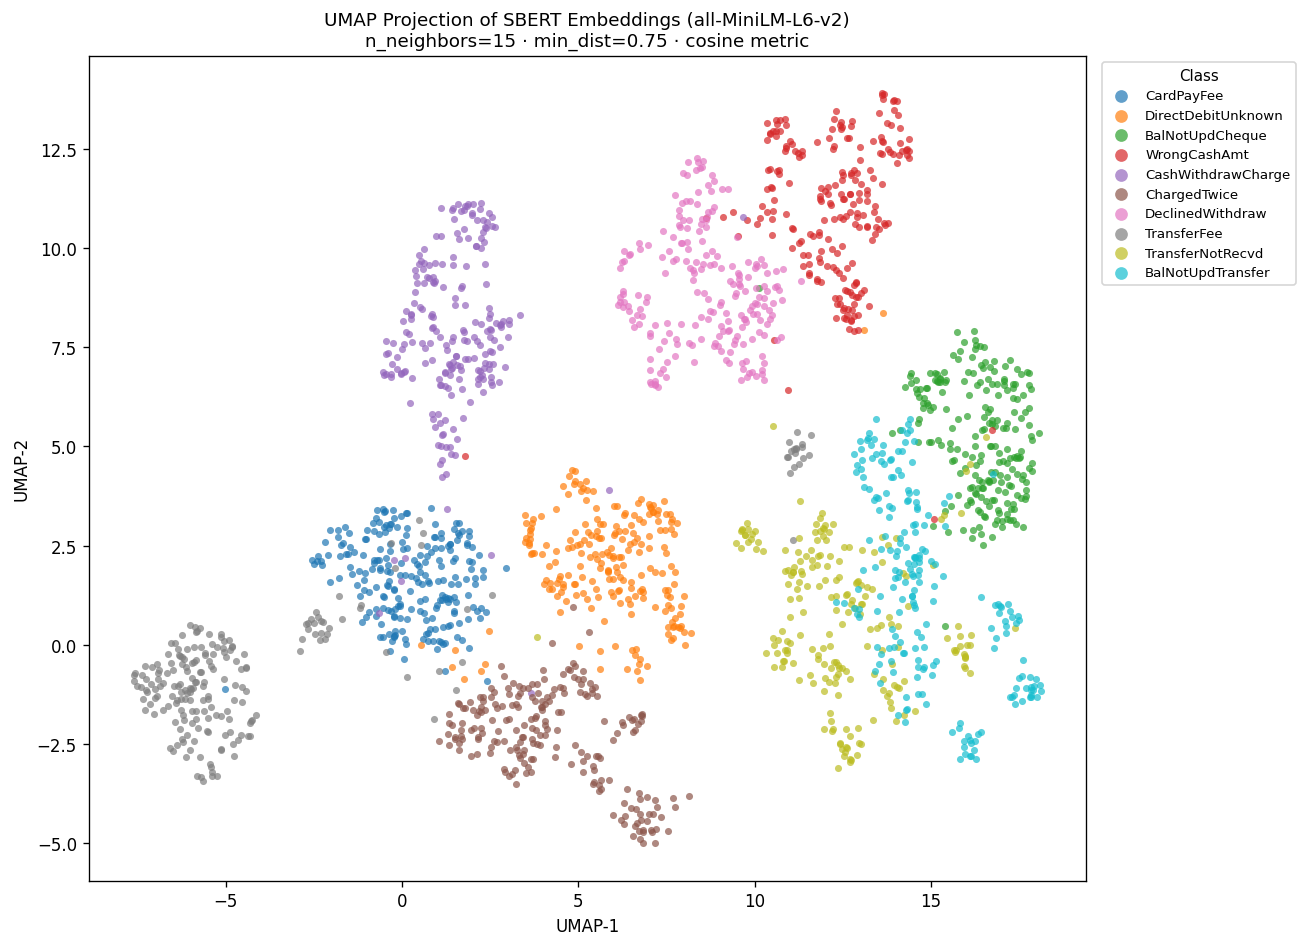

In [31]:
# ── 3. Plot ────────────────────────────────────────────────────────────────────
palette = sns.color_palette("tab10", 10)

fig, ax = plt.subplots(figsize=(11, 8))

for label_id in range(10):
    mask = df["label"].values == label_id
    ax.scatter(
        proj[mask, 0],
        proj[mask, 1],
        c=[palette[label_id]],
        label=SHORT_LABEL[label_id],
        s=18,
        alpha=0.7,
        linewidths=0,
    )

ax.set_title(
    f"UMAP Projection of SBERT Embeddings (all-MiniLM-L6-v2)\n"
    f"n_neighbors=15 · min_dist=0.75 · {metric} metric",
    fontsize=11,
)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(
    title="Class",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    markerscale=1.8,
)
plt.tight_layout()
plt.show()